In [116]:
# 1. Könyvtárak importálása
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 2. Fájlbeolvasás és alap statisztikák
df1 = pd.read_csv('../data/raw/CPU_benchmark_v4.csv')
print(f"Az adathalmaz teljes mérete: {df1.shape[0]} sor és {df1.shape[1]} oszlop")
print(f"Sorok száma hiányzó értékkel: {df1.isnull().any(axis=1).sum()}")

def get_stats(df, name):
    # Hiányzó értékek (NaN)
    null_counts = df.isnull().sum()
    # Nulla értékek (csak numerikus oszlopoknál releváns)
    zero_counts = (df == 0).sum()

    stats = pd.DataFrame({
        'Hiányzó (NaN)': null_counts,
        'Nulla érték (0)': zero_counts
    })
    print(f"\n--- {name} statisztikák ---")
    print(stats)
    return stats

# Megjelen#t3s
stats1 = get_stats(df1, "CPU_benchmark_v4")

# 3. GLOBÁLIS ADATTISZTÍTÁS (Csak egyszer fut le!)
def clean_numeric(val):
    if isinstance(val, str):
        return float(val.replace(',', ''))
    return val

# A powerPerf, price, stb. konverziója stringből floattá a teljes df1-en
numeric_cols = ['price', 'cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores']
for col in numeric_cols:
    if col in df1.columns:
        df1[col] = df1[col].apply(clean_numeric)

# 4. GLOBÁLIS VÁLTOZÓK (Socket csoportosítás)
top_20_sockets = df1['socket'].value_counts().nlargest(20).index
df1['socket_grouped'] = df1['socket'].apply(lambda x: x if x in top_20_sockets else 'Other')

# 5. FEATURE LISTÁK
# A) Korrelációs analízishez (itt vizsgálni akarjuk a powerPerf-et is)
corr_features = ['price', 'cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores', 'testDate', 'category']

# B) TDP modellezéséhez és pótlásához (itt a célváltozó TDP, így az nem lehet bemeneti változó)
features_tdp = ['cpuMark', 'threadMark', 'cores', 'testDate', 'category', 'socket_grouped']

# C) Ár (price) modellezéséhez és pótlásához (itt a célváltozók és deriváltak nincsenek bent)
features_price = ['cpuMark', 'threadMark', 'TDP', 'cores', 'testDate', 'category', 'socket_grouped']

# D) Végső Power Performance predikcióhoz (itt az ár már fontos bemeneti változó)
features_pp = ['price', 'cpuMark', 'threadMark', 'cores', 'testDate', 'category', 'socket_grouped']

Az adathalmaz teljes mérete: 3825 sor és 12 oszlop
Sorok száma hiányzó értékkel: 1887

--- CPU_benchmark_v4 statisztikák ---
             Hiányzó (NaN)  Nulla érték (0)
cpuName                  0                0
price                 1858                0
cpuMark                  0                0
cpuValue              1858                0
threadMark               0                0
threadValue           1858                0
TDP                    685                0
powerPerf              685                0
cores                    0                0
testDate                 0                0
socket                   0                0
category                 0                0


--- TDP és PowerPerf közötti korreláció: -0.1260 ---

--- Price korrelációk ---
price         1.000000
cores         0.767044
cpuMark       0.692600
TDP           0.562841
testDate      0.331479
threadMark    0.253788
powerPerf     0.242099
Name: price, dtype: float64


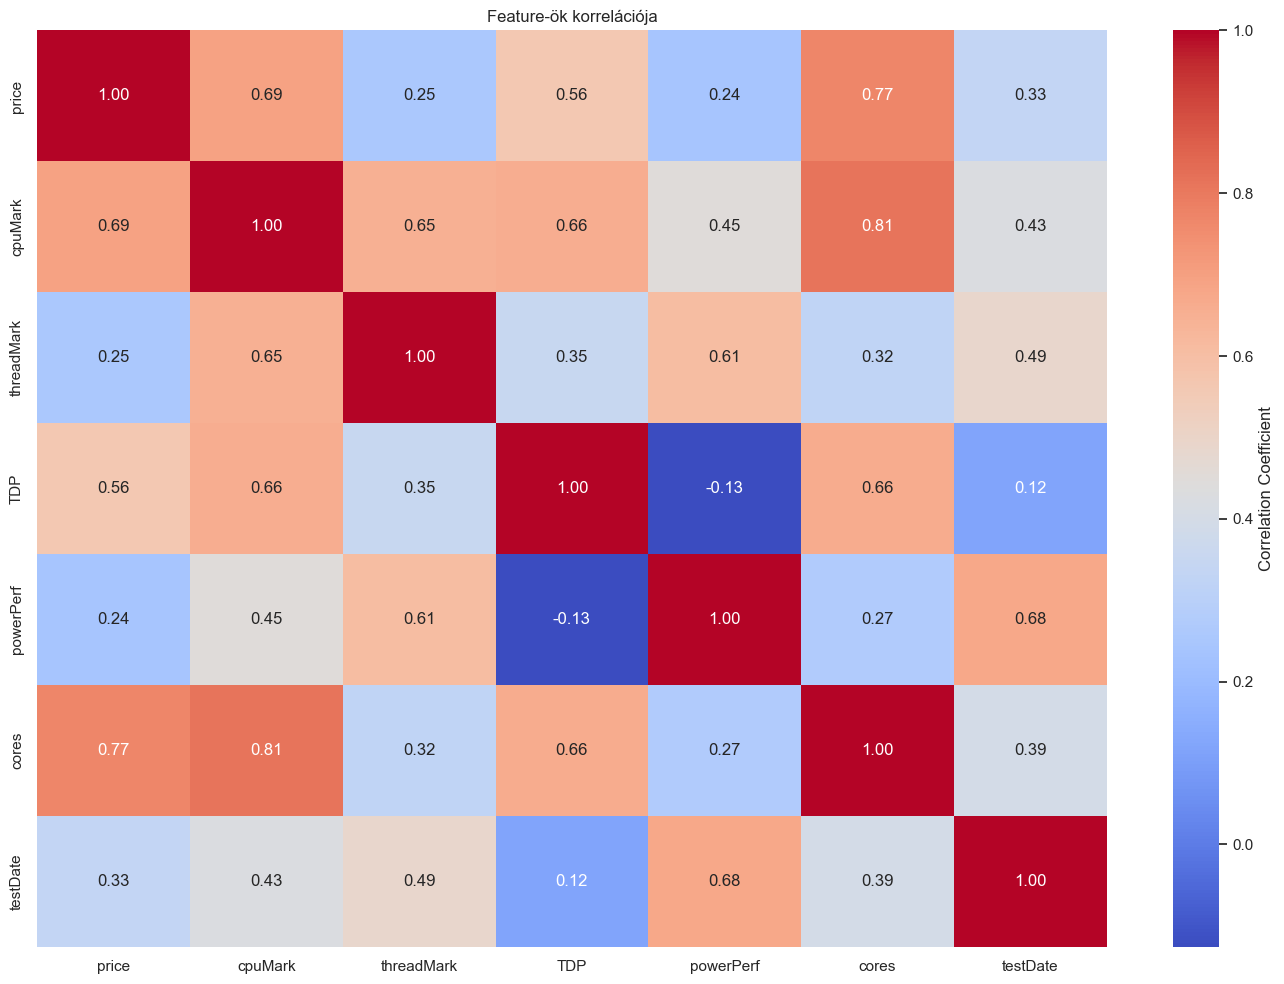

In [117]:
# === Korreláció-analízis ===
# Csak azokat az oszlopokat tartjuk meg, amik ténylegesen benne vannak a df1-ben
existing_features = [f for f in corr_features if f in df1.columns]
df_analysis_clean = df1[existing_features].copy()

# One-Hot Encoding alkalmazása
df_corr_analysis = pd.get_dummies(df_analysis_clean, columns=['category'] if 'category' in df_analysis_clean.columns else [], prefix='cat')

# Csak a numerikus oszlopok kiválasztása
numeric_df = df_corr_analysis.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Biztonságos kiírás: PowerPerf és TDP közötti korreláció
if 'TDP' in corr_matrix.columns and 'powerPerf' in corr_matrix.columns:
    tdp_power_corr = corr_matrix.loc['TDP', 'powerPerf']
    print(f"--- TDP és PowerPerf közötti korreláció: {tdp_power_corr:.4f} ---\n")

# Price korrelációk megjelenítése
if 'price' in corr_matrix.columns:
    price_corr = corr_matrix['price'].sort_values(ascending=False)
    print('--- Price korrelációk ---')
    print(price_corr)

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Feature-ök korrelációja')
    plt.tight_layout()
    plt.show()

C:\Users\gdobo\AppData\Local\Temp\ipykernel_7572\1574066843.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_price_analysis, x='category', y='price', palette='Set2')


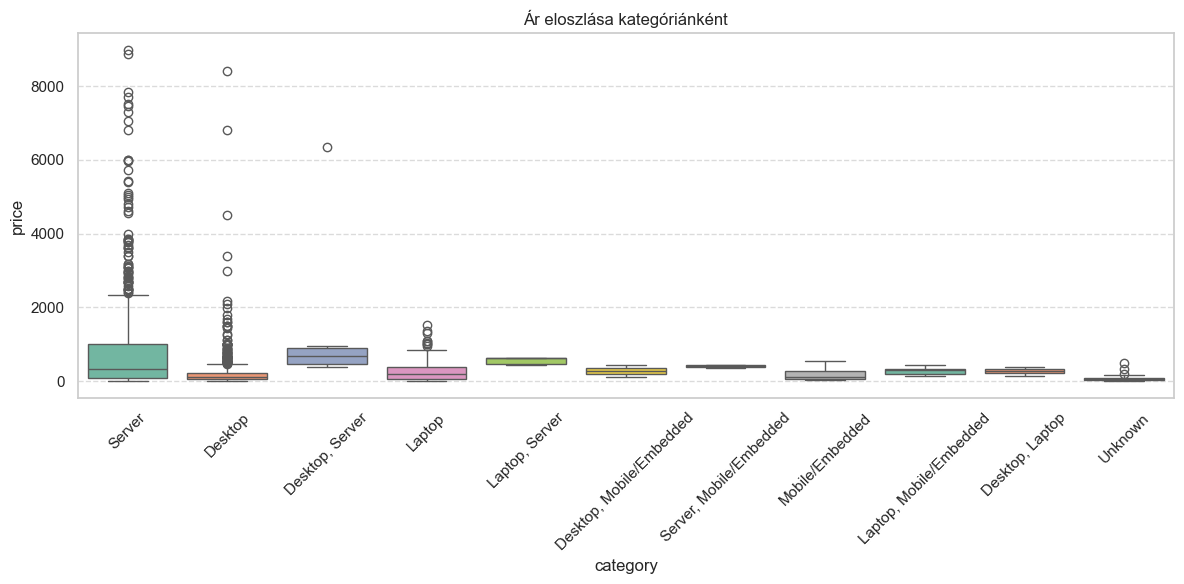

Átlagos árak kategóriánként:


category
Desktop, Server             1577.606667
Server                       874.996928
Laptop, Server               549.791429
Server, Mobile/Embedded      408.500000
Desktop, Mobile/Embedded     284.500000
Laptop, Mobile/Embedded      277.205556
Desktop, Laptop              274.497500
Laptop                       246.257936
Desktop                      223.374915
Mobile/Embedded              183.088235
Unknown                       82.533469
Name: price, dtype: float64

C:\Users\gdobo\AppData\Local\Temp\ipykernel_7572\1574066843.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_sockets_price, x='socket', y='price', palette='viridis')


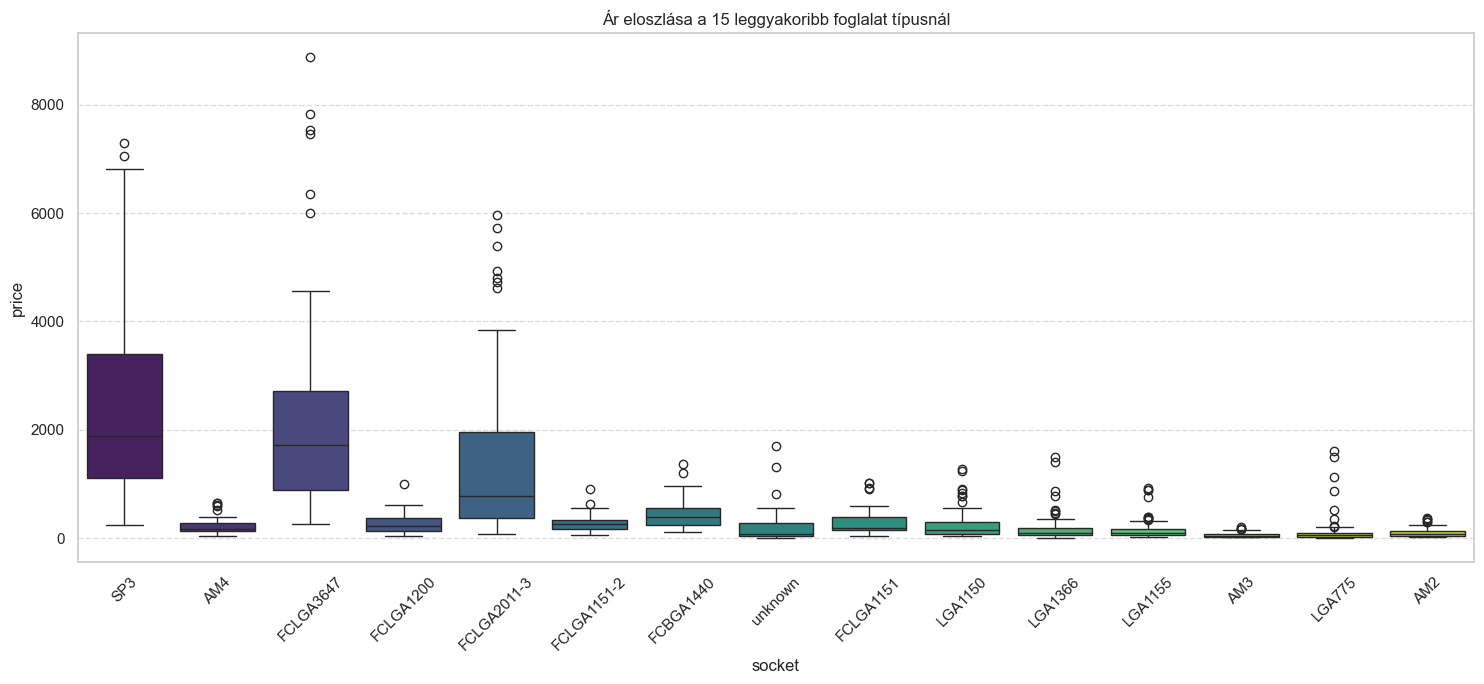

Átlagos árak a leggyakoribb socket-eknél:


socket
SP3            2453.137609
FCLGA3647      2187.002763
FCLGA2011-3    1569.967778
FCBGA1440       436.907308
FCLGA1151       293.376667
FCLGA1151-2     282.030349
LGA1150         266.194167
FCLGA1200       261.678298
AM4             219.615385
unknown         207.348696
LGA1366         198.111167
LGA1155         153.730426
LGA775          135.242716
AM2             102.816444
AM3              60.246111
Name: price, dtype: float64

In [118]:
# Csak azokat a sorokat nézzük, ahol van ár
df_price_analysis = df1.dropna(subset=['price']).copy()

# 1. Ár eloszlása Category szerint
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_price_analysis, x='category', y='price', palette='Set2')
plt.title('Ár eloszlása kategóriánként')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Átlagos árak kategóriánként:")
display(df_price_analysis.groupby('category')['price'].mean().sort_values(ascending=False))

# 2. Ár eloszlása a leggyakoribb Socket-ek szerint (Top 15)
top_sockets = df_price_analysis['socket'].value_counts().nlargest(15).index
df_top_sockets_price = df_price_analysis[df_price_analysis['socket'].isin(top_sockets)]

plt.figure(figsize=(15, 7))
sns.boxplot(data=df_top_sockets_price, x='socket', y='price', palette='viridis')
plt.title('Ár eloszlása a 15 leggyakoribb foglalat típusnál')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Átlagos árak a leggyakoribb socket-eknél:")
display(df_top_sockets_price.groupby('socket')['price'].mean().sort_values(ascending=False))

In [ ]:
# === 1. LÉPCSŐ: TDP Predikciós Modell ===

# Azok a bemeneti változók (alapadatok), amikből a TDP-t meg tudjuk jósolni.
# Itt szigorúan tilos betenni a price-t és a powerPerf-et!
# 1. TANÍTÁS
df_tdp_train = df1.dropna(subset=['TDP'] + features_tdp).copy()

# ITT A VARÁZSLAT: Logaritmizáljuk a célváltozót!
y_tdp_train_log = np.log1p(df_tdp_train['TDP'])
X_tdp_train = pd.get_dummies(df_tdp_train[features_tdp], columns=['category', 'socket_grouped'])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tdp_train, y_tdp_train_log, test_size=0.2, random_state=42)

tdp_model = RandomForestRegressor(n_estimators=100, random_state=42)
tdp_model.fit(X_tdp_train, y_tdp_train_log)

# Eredmények kiíratása
y_pred_t = tdp_model.predict(X_test_t)
print("--- 1. LÉPCSŐ: TDP Predikciós Modell Eredményei ---")
print(f"R2 Score: {r2_score(y_test_t, y_pred_t):.4f}")
print(f"MAE (Átlagos abszolút hiba): {mean_absolute_error(y_test_t, y_pred_t):.2f} Watt")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_t, y_pred_t)):.2f} Watt\n")

# 2. PÓTLÁS
df_cascade = df1.copy()
missing_tdp_mask = df_cascade['TDP'].isnull()
df_missing_tdp = df_cascade[missing_tdp_mask].copy()

if not df_missing_tdp.empty:
    X_missing_tdp = pd.get_dummies(df_missing_tdp[features_tdp], columns=['category', 'socket_grouped'])
    X_missing_tdp = X_missing_tdp.reindex(columns=X_tdp_train.columns, fill_value=0)
    
    # Kiszámoljuk a logaritmikus becslést...
    predicted_tdps_log = tdp_model.predict(X_missing_tdp)
    # ...és VISSZAALAKÍTJUK valós Watt értékre, mielőtt betesszük a df_cascade-be!
    df_cascade.loc[missing_tdp_mask, 'TDP'] = np.expm1(predicted_tdps_log)
    df_cascade['TDP_is_imputed'] = missing_tdp_mask.astype(int)

df_cascade.to_csv('../data/processed/CPU_benchmark_v4_tdp.csv', index=False)
print(f"1. LÉPCSŐ (Log) KÉSZ: Hiányzó TDP pótolva {missing_tdp_mask.sum()} sorban.")

--- 1. LÉPCSŐ: TDP Predikciós Modell Eredményei ---
R2 Score: 0.9771
MAE (Átlagos abszolút hiba): 0.09 Watt
RMSE: 0.13 Watt

1. LÉPCSŐ (Log) KÉSZ: Hiányzó TDP pótolva 685 sorban.


In [120]:
# === Finding best Price regression ===
# Adatok előkészítése: itt a df1 már a tisztított formátumú
df_price_base = df1.dropna(subset=["price", "cpuMark", "threadMark", "TDP", "cores", "testDate", "category"]).copy()

results_list_price = []

# --- 1. Modell eredmények (eredeti adatokon + Socket) ---
# Itt már nyugodtan használhatjuk a fenti 'features_price' listát
y_orig_price = df_price_base["price"]
X_orig_price = pd.get_dummies(df_price_base[features_price], columns=["category", "socket_grouped"])
X_train_orig_price, X_test_orig_price, y_train_orig_price, y_test_orig_price = train_test_split(X_orig_price, y_orig_price, test_size=0.2, random_state=42)

models_orig_price = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "RandomForest_Original": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("--- Modell eredmények (eredeti adatokon - Price) ---")
for name, model in models_orig_price.items():
    model.fit(X_train_orig_price, y_train_orig_price)
    y_pred = model.predict(X_test_orig_price)
    rmse = np.sqrt(mean_squared_error(y_test_orig_price, y_pred))
    mae = mean_absolute_error(y_test_orig_price, y_pred)
    r2 = r2_score(y_test_orig_price, y_pred)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 2. Modell eredmények (logaritmikus transzformációval + Socket) ---
y_orig_log_price = np.log1p(y_orig_price)
X_train_orig_log_price, X_test_orig_log_price, y_train_orig_log_price, y_test_orig_log_price = train_test_split(X_orig_price, y_orig_log_price, test_size=0.2, random_state=42)

models_log_orig_price = {
    "Linear_LogTransformed": LinearRegression(),
    "Ridge_LogTransformed": Ridge(alpha=10.0),
    "Lasso_LogTransformed": Lasso(alpha=0.1),
    "ElasticNet_LogTransformed": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "RandomForest_LogTransformed": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("\n--- Modell eredmények (log transzformáció - Price) ---")
for name, model in models_log_orig_price.items():
    model.fit(X_train_orig_log_price, y_train_orig_log_price)
    y_pred_log = model.predict(X_test_orig_log_price)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test_orig_price, y_pred))
    mae = mean_absolute_error(y_test_orig_price, y_pred)
    r2 = r2_score(y_test_orig_price, y_pred)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 3. Modell eredmények (outlierek kezelése IQR-rel) ---
Q1_price = df_price_base['price'].quantile(0.25)
Q3_price = df_price_base['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

df_filtered_price = df_price_base[(df_price_base['price'] >= lower_bound_price) & (df_price_base['price'] <= upper_bound_price)].copy()

y_filt_price = df_filtered_price["price"]
X_filt_price = pd.get_dummies(df_filtered_price[features_price], columns=["category", "socket_grouped"])
X_train_filt_price, X_test_filt_price, y_train_filt_price, y_test_filt_price = train_test_split(X_filt_price, y_filt_price, test_size=0.2, random_state=42)

models_filtered_price = {
    "Linear_IQR": LinearRegression(),
    "RandomForest_IQR": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("\n--- Modell eredmények (outlierek kezelése IQR-rel - Price) ---")
for name, model in models_filtered_price.items():
    model.fit(X_train_filt_price, y_train_filt_price)
    y_pred_filt = model.predict(X_test_filt_price)
    rmse_filt = np.sqrt(mean_squared_error(y_test_filt_price, y_pred_filt))
    mae_filt = mean_absolute_error(y_test_filt_price, y_pred_filt)
    r2_filt = r2_score(y_test_filt_price, y_pred_filt)
    results_list_price.append({'Modell': f"{name}", 'RMSE': rmse_filt, 'MAE': mae_filt, 'R2 Score': r2_filt})

comparison_df_price = pd.DataFrame(results_list_price).sort_values(by="R2 Score", ascending=False)
display(comparison_df_price)

--- Modell eredmények (eredeti adatokon - Price) ---

--- Modell eredmények (log transzformáció - Price) ---

--- Modell eredmények (outlierek kezelése IQR-rel - Price) ---


,Modell,RMSE,MAE,R2 Score
11,RandomForest_IQR,119.342221,80.809237,0.606080
3,ElasticNet,529.129353,259.153176,0.534723
1,Ridge,536.806687,261.407296,0.521124
9,RandomForest_LogTransformed,537.418863,197.198897,0.520031
2,Lasso,546.726809,267.841553,0.503261
0,Linear,547.050280,268.850281,0.502673
10,Linear_IQR,134.150785,95.715361,0.502255
4,RandomForest_Original,554.475671,227.829474,0.489080
6,Ridge_LogTransformed,565.538305,216.397358,0.468490
5,Linear_LogTransformed,569.776523,224.507232,0.460494


In [121]:
# === 2. LÉPCSŐ: Price Predikciós Modell ===

# 1. TANÍTÁS: Szigorúan az eredeti, valós Price-szal ÉS valós TDP-vel rendelkező adatokon!
# Itt df1-et használunk, NEM a df_cascade-et!
df_price_train = df1.dropna(subset=['price'] + features_price).copy()

# Logaritmizáljuk az árat!
y_price_train_log = np.log1p(df_price_train['price'])
X_price_train = pd.get_dummies(df_price_train[features_price], columns=['category', 'socket_grouped'])

# Price Modell betanítása a tiszta adatokon
price_model = RandomForestRegressor(n_estimators=100, random_state=42)
price_model.fit(X_price_train, y_price_train_log)

# 2. PÓTLÁS (Imputation): Ahol az eredeti adatbázisban (df_cascade) hiányzott az ár.
missing_price_mask = df_cascade['price'].isnull()
df_missing_price = df_cascade[missing_price_mask].copy()

if not df_missing_price.empty:
    X_missing_price = pd.get_dummies(df_missing_price[features_price], columns=['category', 'socket_grouped'])
    X_missing_price = X_missing_price.reindex(columns=X_price_train.columns, fill_value=0)
    
    # Becsült Árak beírása a cascade adatbázisba
    df_cascade.loc[missing_price_mask, 'price'] = np.expm1(price_model.predict(X_missing_price))
    df_cascade['price_is_imputed'] = missing_price_mask.astype(int)

# Opcionális: Származtatott értékek (cpuValue, threadValue) újraszámolása a már teli adatbázisban
df_cascade['cpuValue'] = df_cascade['cpuMark'] / df_cascade['price']
df_cascade['threadValue'] = df_cascade['threadMark'] / df_cascade['price']

print(f"2. LÉPCSŐ KÉSZ: Hiányzó Price értékek pótolva {missing_price_mask.sum()} sorban.")

df_cascade.to_csv('../data/processed/CPU_benchmark_v4_tdp+price.csv', index=False)
print('Kiegészített adathalmaz elmentve!')

2. LÉPCSŐ KÉSZ: Hiányzó Price értékek pótolva 1858 sorban.
Kiegészített adathalmaz elmentve!


In [122]:
# === Finding best Power Performance regression ===

# Adatok előkészítése: A már imputált (árral kiegészített) adatbázist használjuk
# Csak azokat a sorokat nézzük, ahol a powerPerf NEM hiányzik (ez a gold standard tanítóhalmaz)
df_pp_base = df1.dropna(subset=['powerPerf'] + features_pp).copy()

results_list_pp = []

# Itt a features_pp globális listát használjuk (amiben benne van a pótolt price is!)
y_orig_pp = df_pp_base["powerPerf"]
X_orig_pp = pd.get_dummies(df_pp_base[features_pp], columns=["category", "socket_grouped"])

# --- 1. Modell eredmények (eredeti adatokon) ---
X_train_orig_pp, X_test_orig_pp, y_train_orig_pp, y_test_orig_pp = train_test_split(X_orig_pp, y_orig_pp, test_size=0.2, random_state=42)

models_orig_pp = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "RandomForest_Original": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("--- Modell eredmények (eredeti adatokon - PowerPerf) ---")
for name, model in models_orig_pp.items():
    model.fit(X_train_orig_pp, y_train_orig_pp)
    y_pred = model.predict(X_test_orig_pp)
    rmse = np.sqrt(mean_squared_error(y_test_orig_pp, y_pred))
    mae = mean_absolute_error(y_test_orig_pp, y_pred)
    r2 = r2_score(y_test_orig_pp, y_pred)
    results_list_pp.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 2. Modell eredmények (logaritmikus transzformációval) ---
# Biztonságos logaritmus (log1p), ha lennének 0 közeli értékek
y_orig_log_pp = np.log1p(y_orig_pp)
X_train_orig_log_pp, X_test_orig_log_pp, y_train_orig_log_pp, y_test_orig_log_pp = train_test_split(X_orig_pp, y_orig_log_pp, test_size=0.2, random_state=42)

models_log_orig_pp = {
    "Linear_LogTransformed": LinearRegression(),
    "Ridge_LogTransformed": Ridge(alpha=10.0),
    "Lasso_LogTransformed": Lasso(alpha=0.1),
    "ElasticNet_LogTransformed": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "RandomForest_LogTransformed": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("\n--- Modell eredmények (log transzformáció - PowerPerf) ---")
for name, model in models_log_orig_pp.items():
    model.fit(X_train_orig_log_pp, y_train_orig_log_pp)
    y_pred_log = model.predict(X_test_orig_log_pp)
    y_pred = np.expm1(y_pred_log) # Visszaalakítás a valós skálára
    rmse = np.sqrt(mean_squared_error(y_test_orig_pp, y_pred))
    mae = mean_absolute_error(y_test_orig_pp, y_pred)
    r2 = r2_score(y_test_orig_pp, y_pred)
    results_list_pp.append({'Modell': f"{name}", 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# --- 3. Modell eredmények (outlierek kezelése IQR-rel) ---
Q1_pp = df_pp_base['powerPerf'].quantile(0.25)
Q3_pp = df_pp_base['powerPerf'].quantile(0.75)
IQR_pp = Q3_pp - Q1_pp
lower_bound_pp = Q1_pp - 1.5 * IQR_pp
upper_bound_pp = Q3_pp + 1.5 * IQR_pp

df_filtered_pp = df_pp_base[(df_pp_base['powerPerf'] >= lower_bound_pp) & (df_pp_base['powerPerf'] <= upper_bound_pp)].copy()

y_filt_pp = df_filtered_pp["powerPerf"]
X_filt_pp = pd.get_dummies(df_filtered_pp[features_pp], columns=["category", "socket_grouped"])

# Biztosítjuk, hogy a szűrt adatok oszlopai megegyezzenek az eredeti oszlopokkal (ha kiesett volna egy socket kategória)
X_filt_pp = X_filt_pp.reindex(columns=X_orig_pp.columns, fill_value=0)

X_train_filt_pp, X_test_filt_pp, y_train_filt_pp, y_test_filt_pp = train_test_split(X_filt_pp, y_filt_pp, test_size=0.2, random_state=42)

models_filtered_pp = {
    "Linear_IQR": LinearRegression(),
    "Ridge_IQR": Ridge(alpha=10.0),
    "Lasso_IQR": Lasso(alpha=0.1),
    "ElasticNet_IQR": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "RandomForest_IQR": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("\n--- Modell eredmények (outlierek kezelése IQR-rel - PowerPerf) ---")
print(f"Eredeti sorok száma: {len(df_pp_base)}")
print(f"Szűrt sorok száma (PowerPerf outlierek nélkül): {len(df_filtered_pp)}\n")

for name, model in models_filtered_pp.items():
    model.fit(X_train_filt_pp, y_train_filt_pp)
    y_pred_filt = model.predict(X_test_filt_pp)
    rmse_filt = np.sqrt(mean_squared_error(y_test_filt_pp, y_pred_filt))
    mae_filt = mean_absolute_error(y_test_filt_pp, y_pred_filt)
    r2_filt = r2_score(y_test_filt_pp, y_pred_filt)
    results_list_pp.append({'Modell': f"{name}", 'RMSE': rmse_filt, 'MAE': mae_filt, 'R2 Score': r2_filt})

# --- Eredmények összefoglalása ---
comparison_df_pp = pd.DataFrame(results_list_pp).sort_values(by="R2 Score", ascending=False)
display(comparison_df_pp)

--- Modell eredmények (eredeti adatokon - PowerPerf) ---


c:\Users\gdobo\miniconda3\envs\cpu-perf-pred\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.458e+03, tolerance: 2.223e+03
  model = cd_fast.enet_coordinate_descent(



--- Modell eredmények (log transzformáció - PowerPerf) ---

--- Modell eredmények (outlierek kezelése IQR-rel - PowerPerf) ---
Eredeti sorok száma: 1938
Szűrt sorok száma (PowerPerf outlierek nélkül): 1833



,Modell,RMSE,MAE,R2 Score
14,RandomForest_IQR,32.694010,18.522657,0.831630
4,RandomForest_Original,52.379287,25.013004,0.821785
9,RandomForest_LogTransformed,53.104675,24.239174,0.816815
10,Linear_IQR,38.982418,26.017083,0.760632
12,Lasso_IQR,39.145785,25.871274,0.758621
11,Ridge_IQR,39.179924,25.853598,0.758200
13,ElasticNet_IQR,40.369912,26.735855,0.743289
5,Linear_LogTransformed,69.631403,38.013539,0.685054
6,Ridge_LogTransformed,69.816987,37.792492,0.683373
2,Lasso,71.540100,44.045333,0.667552


In [123]:
# === 3. LÉPCSŐ: Power Performance Predikciós Modell (Fő feladat) ===

# 1. TANÍTÁS: Valós PowerPerf és Valós Price megléte esetén (Eredeti df1-ből származtatva)
# (A df1-ben ha van powerPerf, akkor van TDP is)
df_pp_train = df1.dropna(subset=['powerPerf'] + features_pp).copy()

# Logaritmizáljuk a hatékonyságot!
y_pp_train_log = np.log1p(df_pp_train['powerPerf'])
X_pp_train = pd.get_dummies(df_pp_train[features_pp], columns=['category', 'socket_grouped'])

pp_model = RandomForestRegressor(n_estimators=100, random_state=42)
pp_model.fit(X_pp_train, y_pp_train_log)

# 2. PÓTLÁS (Imputation): Rászabadítjuk a modellt a df_cascade hiányzó soraira
df_final = df_cascade.copy()
missing_pp_mask = df_final['powerPerf'].isnull()
df_missing_pp = df_final[missing_pp_mask].copy()

if not df_missing_pp.empty:
    X_missing_pp = pd.get_dummies(df_missing_pp[features_pp], columns=['category', 'socket_grouped'])
    X_missing_pp = X_missing_pp.reindex(columns=X_pp_train.columns, fill_value=0)
    
    # VÉGSŐ lépés: Becsült PowerPerf beírása a teljesen kiegészített adatbázisba
    df_final.loc[missing_pp_mask, 'powerPerf'] = np.expm1(pp_model.predict(X_missing_pp))
    df_final['powerPerf_is_imputed'] = missing_pp_mask.astype(int)

print(f"3. LÉPCSŐ KÉSZ: Hiányzó Power Performance értékek pótolva {missing_pp_mask.sum()} sorban.")

# A TÖKÉLETES, hiba-akkumuláció mentes adatbázis mentése!
df_final.to_csv('../data/processed/CPU_benchmark_final_imputed.csv', index=False)
print("A végső, kiegészített adatbázis sikeresen elmentve!")

3. LÉPCSŐ KÉSZ: Hiányzó Power Performance értékek pótolva 685 sorban.
A végső, kiegészített adatbázis sikeresen elmentve!


In [124]:
# === Betanított modell és oszlopstruktúra mentése a webapphoz ===
import joblib
import os

# Mappa létrehozása, ha még nem létezne
os.makedirs('../models', exist_ok=True)

# 1. TDP modell és oszlopok mentése
joblib.dump(tdp_model, '../models/tdp_rf_model.pkl')
joblib.dump(list(X_tdp_train.columns), '../models/tdp_model_columns.pkl')

# 2. Price (Ár) modell és oszlopok mentése
joblib.dump(price_model, '../models/price_rf_model.pkl')
joblib.dump(list(X_price_train.columns), '../models/price_model_columns.pkl')

# 3. Power Performance modell és oszlopok mentése
joblib.dump(pp_model, '../models/powerPerf_rf_model.pkl')
joblib.dump(list(X_pp_train.columns), '../models/powerPerf_model_columns.pkl')

print("Minden modell (TDP, Price, PowerPerf) és oszlopstruktúra sikeresen elmentve a ../models mappába!")

Minden modell (TDP, Price, PowerPerf) és oszlopstruktúra sikeresen elmentve a ../models mappába!


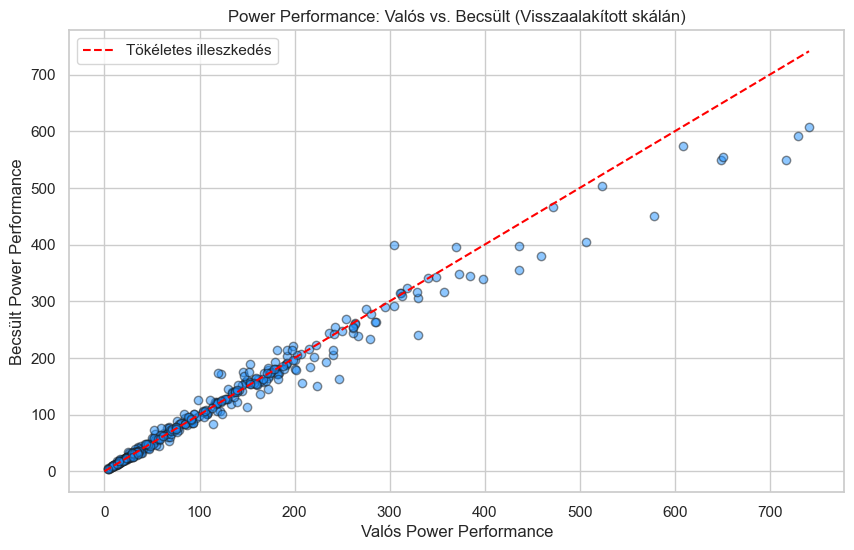

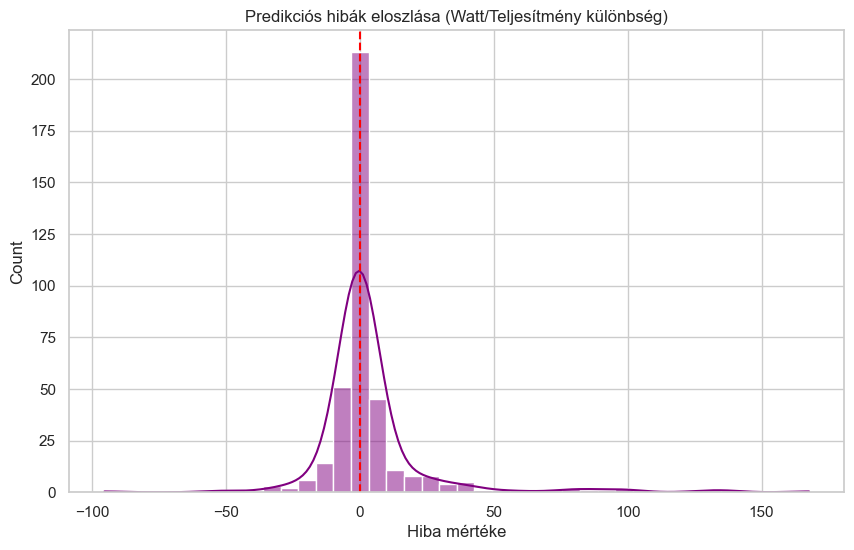

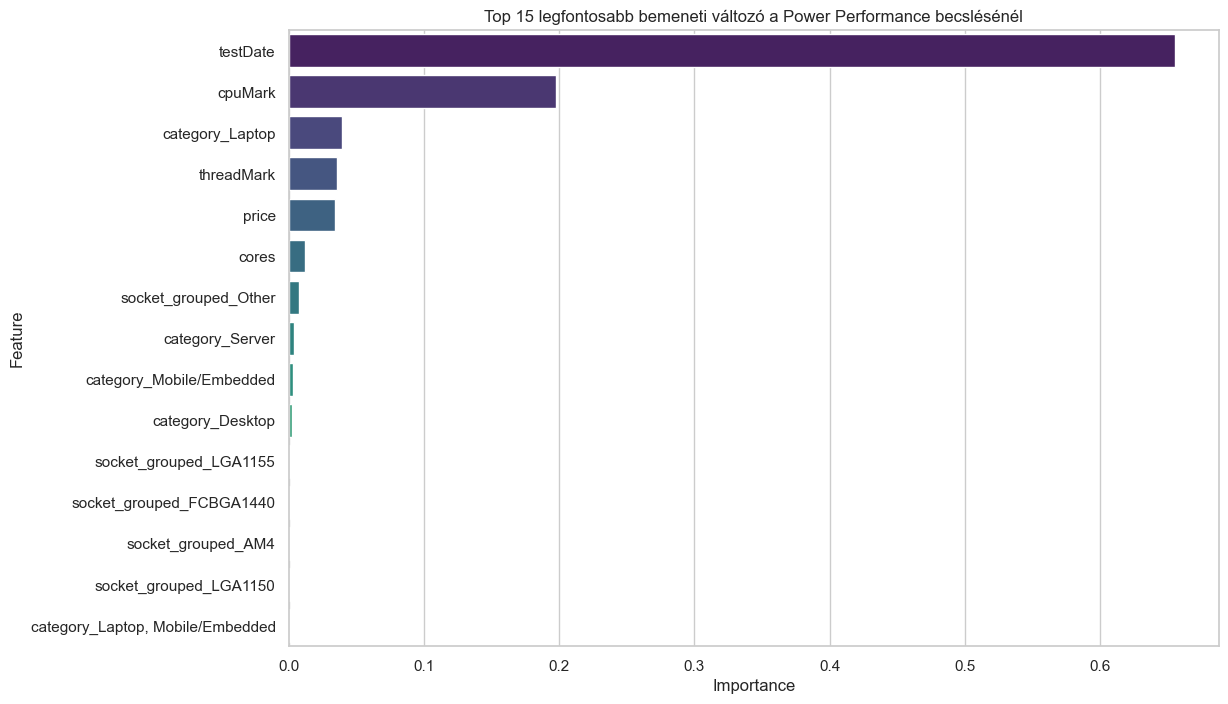

In [125]:
# === TELJESÍTMÉNY ANALÍZIS ÉS VIZUALIZÁCIÓ ===

# 1. Adatok szétválasztása teszteléshez (mivel a pp_model a teljes X_pp_train-en lett tanítva)
# Csinálunk egy gyors split-et csak a vizualizáció kedvéért
X_train_v, X_test_v, y_train_v_log, y_test_v_log = train_test_split(
    X_pp_train, y_pp_train_log, test_size=0.2, random_state=42
)

# Predikció a logaritmikus teszthalmazon
y_pred_log = pp_model.predict(X_test_v)

# VISSZAALAKÍTÁS a valós skálára (Log -> Valós érték)
y_test_actual = np.expm1(y_test_v_log)
y_pred_actual = np.expm1(y_pred_log)

sns.set_theme(style="whitegrid")

# --- A) Valós vs. Becsült értékek ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='dodgerblue', edgecolor='k')
max_val = max(y_test_actual.max(), y_pred_actual.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Tökéletes illeszkedés')
plt.title('Power Performance: Valós vs. Becsült (Visszaalakított skálán)')
plt.xlabel('Valós Power Performance')
plt.ylabel('Becsült Power Performance')
plt.legend()
plt.show()

# --- B) Hibák (Reziduumok) eloszlása ---
residuals = y_test_actual - y_pred_actual
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Predikciós hibák eloszlása (Watt/Teljesítmény különbség)')
plt.xlabel('Hiba mértéke')
plt.show()

# --- C) Feature Importance (Top 15) ---
importance = pd.DataFrame({
    'Feature': X_pp_train.columns,
    'Importance': pp_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance.head(15), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 legfontosabb bemeneti változó a Power Performance becslésénél')
plt.show()